# Computing Bottleneck Analysis

## Introduction

Sometimes I enjoy gaming on my PC, but I built it around 8 years ago, and on a budget. Therefore, it can sometimes struggle with performance. I was interested in gathering some data on my hardware utilisation and analysing the collected data to identify any obvious bottlenecks. With the insights gained from this data, the goal is to identify key issues or components that are consistently throttling game performance, which can then inform future purchases or upgrades.

Hardware data was collected with [HWiNFO](https://www.hwinfo.com/).

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

from config import RAW_DATA_FILE_PATH, COLS

In [2]:
files = [
    os.path.join(RAW_DATA_FILE_PATH, f) for f in os.listdir(RAW_DATA_FILE_PATH)
]

dfs: list[pd.DataFrame] = []
for f in files:
    df = pd.read_csv(
        f, encoding="latin-1", usecols=COLS, skipfooter=2, engine="python"
    )  # HWIN adds info on final line we want to skip
    df["Series"] = os.path.basename(f)
    dfs.append(df)

panel = pd.concat(dfs, ignore_index=True)
panel

,Date,Time,Physical Memory Load [%],Max CPU/Thread Usage [%],Total CPU Usage [%],GPU Utilization [%],Average Effective Clock [MHz],Total CPU Utility [%],CPU (Tctl/Tdie) [°C],CPU Package Power [W],...,GPU D3D Usage [%],Framerate Presented (avg) [FPS],Framerate Presented (1% low) [FPS],Framerate Presented (0.1% low) [FPS],Frame Time Presented (avg) [ms],GPU Busy (avg) [ms],GPU Wait (avg) [ms],CPU Busy (avg) [ms],CPU Wait (avg) [ms],Series
0,13.2.2026,20:44:47.093,71.7,82.9,72.1,0.0,2880.1,68.9,45.2,15.070,...,1.3,15.8,1.9,1.9,63.25,0.12,37.07,63.10,0.15,eu4_2026_02_13.CSV
1,13.2.2026,20:44:49.097,72.0,71.9,63.3,0.0,2533.1,60.5,45.6,13.901,...,0.3,4.0,1.2,1.2,250.26,0.19,220.78,250.13,0.12,eu4_2026_02_13.CSV
2,13.2.2026,20:44:51.099,72.1,100.0,99.0,0.0,3787.4,92.1,47.1,15.859,...,0.1,3.0,1.2,1.2,328.30,0.10,0.00,328.17,0.14,eu4_2026_02_13.CSV
3,13.2.2026,20:44:53.094,72.0,100.0,99.4,0.0,3792.5,92.2,47.5,15.850,...,0.1,2.3,1.2,1.2,442.06,0.10,0.00,441.95,0.12,eu4_2026_02_13.CSV
4,13.2.2026,20:44:57.093,71.9,99.2,98.6,0.0,3774.8,91.6,47.8,16.010,...,3.2,23.7,8.5,8.5,42.26,0.10,0.00,42.14,0.12,eu4_2026_02_13.CSV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39815,15.2.2026,22:54:55.596,50.7,88.4,87.2,1.0,3389.6,81.5,60.0,16.711,...,2.0,39.3,7.0,7.0,25.45,0.29,0.01,25.02,0.42,xcom2_2026_02_15.CSV
39816,15.2.2026,22:54:57.601,50.1,68.0,65.8,0.0,2652.9,61.8,56.9,15.177,...,1.8,42.8,19.4,19.4,23.36,0.24,0.00,22.99,0.37,xcom2_2026_02_15.CSV
39817,15.2.2026,22:54:59.595,49.8,41.4,34.2,30.0,1463.3,33.4,53.8,11.815,...,2.0,41.1,19.6,19.6,24.36,0.24,0.00,23.97,0.39,xcom2_2026_02_15.CSV
39818,15.2.2026,22:55:1.596,49.2,26.7,21.6,0.0,1117.9,24.5,50.9,10.389,...,8.0,38.9,19.9,19.9,25.67,0.52,0.00,25.32,0.36,xcom2_2026_02_15.CSV


In [3]:
list(panel)

['Date',
 'Time',
 'Physical Memory Load [%]',
 'Max CPU/Thread Usage [%]',
 'Total CPU Usage [%]',
 'GPU Utilization [%]',
 'Average Effective Clock [MHz]',
 'Total CPU Utility [%]',
 'CPU (Tctl/Tdie) [°C]',
 'CPU Package Power [W]',
 'CPU TDC Limit [%]',
 'GPU Thermal Diode [°C]',
 'GPU Core Power [W]',
 'GPU Clock [MHz]',
 'GPU D3D Usage [%]',
 'Framerate Presented (avg) [FPS]',
 'Framerate Presented (1% low) [FPS]',
 'Framerate Presented (0.1% low) [FPS]',
 'Frame Time Presented (avg) [ms]',
 'GPU Busy (avg) [ms]',
 'GPU Wait (avg) [ms]',
 'CPU Busy (avg) [ms]',
 'CPU Wait (avg) [ms]',
 'Series']

## Variables
Below is a list of all the variables in the dataset and a brief explanation of them.
- Physical Memory Load [%] — RAM pressure
- Max CPU/Thread Usage [%] — load on most used thread
- Total CPU Usage [%] — overall CPU load
- Total CPU Utility [%] — how efficiently the CPU is being used
- GPU Utilization [%] — GPU load
- GPU D3D Usage [%] — measures GPU time spent on actual game rendering, not background other tasks
- Average Effective Clock [MHz] — if this drops under load, CPU throttling is occuring
- GPU Clock [MHz] — if this drops under load, GPU throttling is occuring
- CPU (Tctl/Tdie) [°C] — whether CPU is self-throttling due to high temps
- GPU Thermal Diode [°C] — whether CPU is self-throttling due to high temps
- CPU Package Power [W] — whether CPU is power-limited
- GPU Core Power [W] — whether GPU is power-limited
- CPU TDC Limit [%] — current limit from motherboard. Performance is throttled by motherboard power delivery
- Framerate Presented (avg) [FPS] + (1% low) [FPS] + (0.1% low) [FPS] — the actual outcome, dependent variable
- Frame Time Presented (avg) [ms] - inverse of framerate. correlated, but can add clarity.
- CPU Busy (avg) [ms] vs GPU Busy (avg) [ms] — most direct bottleneck indicator: whichever is higher is the bottleneck
- CPU Wait (avg) [ms] vs GPU Wait (avg) [ms] — complements above, showing direction of bottleneck

## Data cleaning

First, let's create proper a datetime column and drop parent cols. This will help us with graphing.

In [4]:
panel["Datetime"] = pd.to_datetime(
    panel["Date"] + " " + panel["Time"], dayfirst=True
)
panel = panel.drop(["Date", "Time"], axis=1)

Let's also check for any null or NA data in the dataframe.

In [21]:
panel.loc[panel.isna().any(axis=1)]

,Physical Memory Load [%],Max CPU/Thread Usage [%],Total CPU Usage [%],GPU Utilization [%],Average Effective Clock [MHz],Total CPU Utility [%],CPU (Tctl/Tdie) [°C],CPU Package Power [W],CPU TDC Limit [%],GPU Thermal Diode [°C],...,Framerate Presented (avg) [FPS],Framerate Presented (1% low) [FPS],Framerate Presented (0.1% low) [FPS],Frame Time Presented (avg) [ms],GPU Busy (avg) [ms],GPU Wait (avg) [ms],CPU Busy (avg) [ms],CPU Wait (avg) [ms],Series,Datetime


Let's graph CPU vs GPU Busy to get a quick overview of the data. We use a rolling average because without it, the data is a wall of noise. Metrics can fluctuate heavily from frame-to-frame, so using a rolling average helps us reveal the underlying trend.

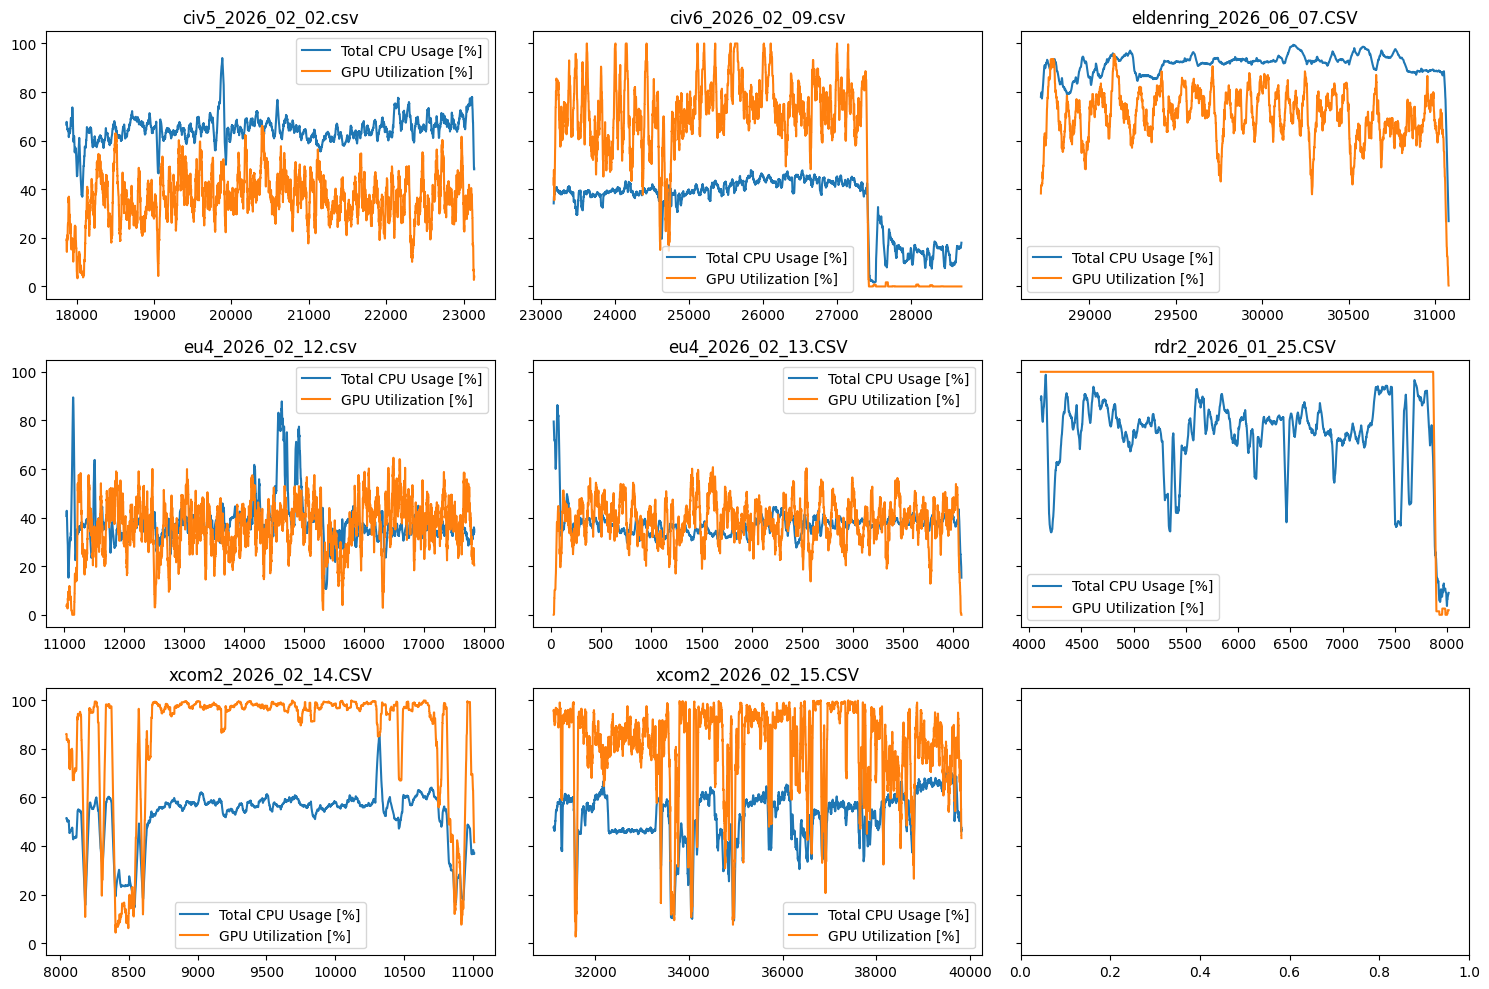

In [6]:
fig, ax = plt.subplots(3, 3, sharey=True, figsize=(15, 10))
for i, (name, df) in enumerate(panel.groupby("Series")):
    row, col = i // 3, i % 3  # map flat index to 2D grid position
    df[["Total CPU Usage [%]", "GPU Utilization [%]"]].rolling(
        window=30
    ).mean().plot(ax=ax[row, col])
    ax[row, col].set_title(name)
fig.tight_layout()
plt.show()

Immediately obvious, is that some further data cleaning is required. Data was recorded by pressing a 'logging' button, and this logging was sometimes ended significantly after the game was stopped. This results in the sudden (and in the civ6 series, quite prolonged) drop in utilisation.

Let's create a function to trim the beginnning and end of each series, where D3D (game frame rendering) is significantly low. This will help us focus only on relevant data.

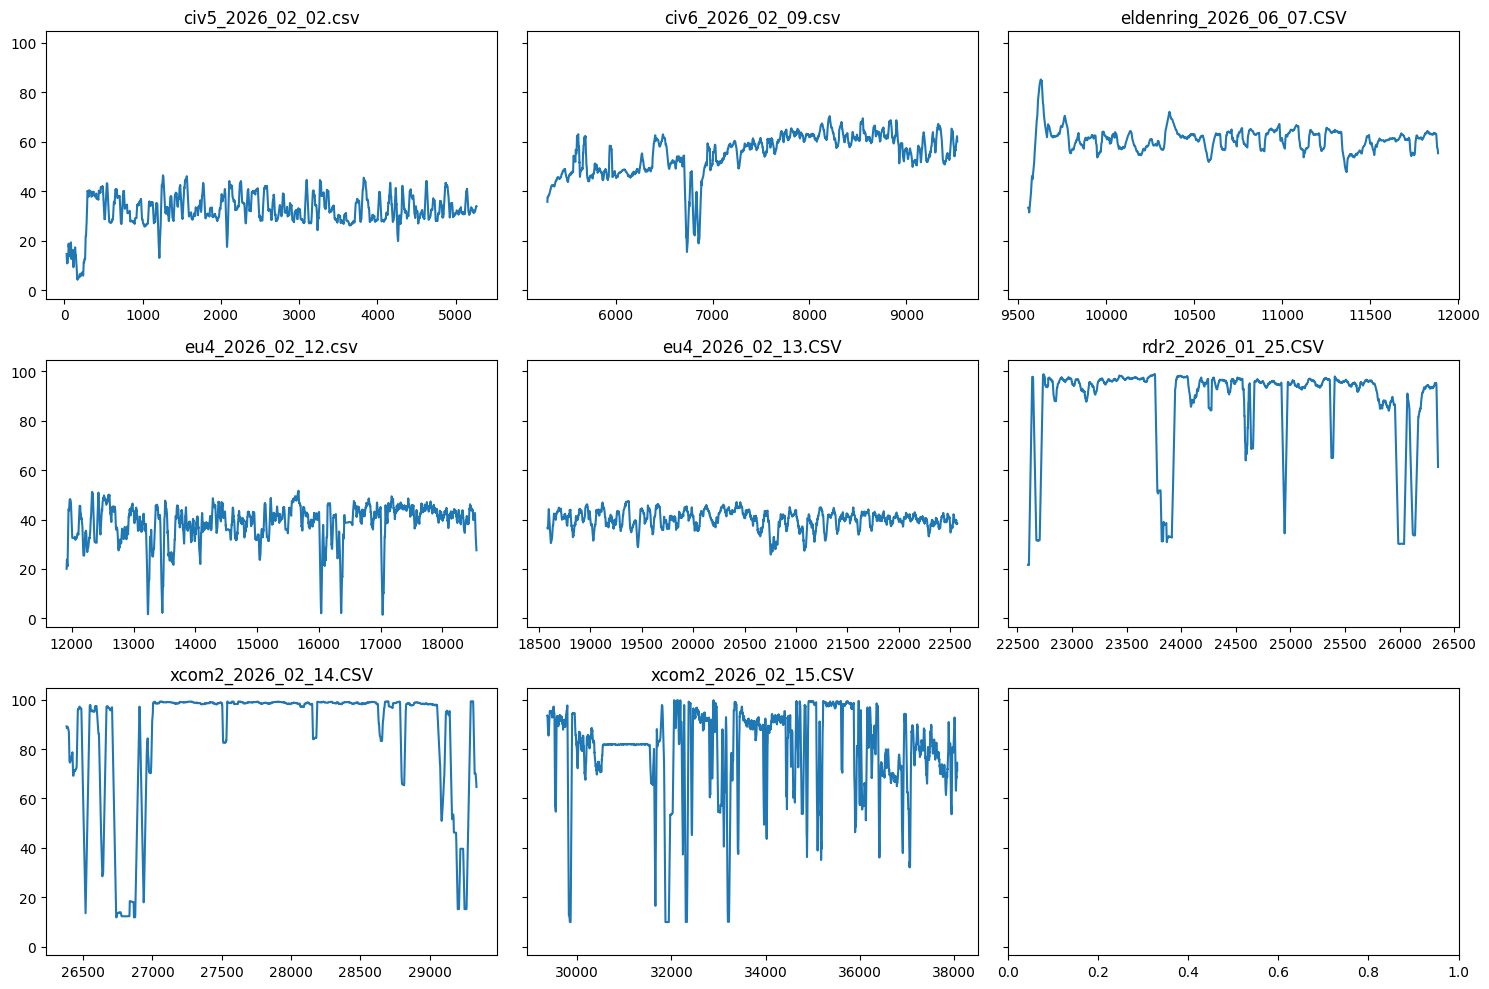

In [7]:
def trim_data(df: pd.DataFrame, threshold: int = 15) -> pd.DataFrame:
    last_active = df["GPU D3D Usage [%]"].gt(threshold).where(lambda x: x).last_valid_index()
    first_active = df["GPU D3D Usage [%]"].gt(threshold).where(lambda x: x).first_valid_index()
    return df.loc[first_active:last_active]

panel = pd.concat([trim_data(df) for _, df in panel.groupby("Series")], ignore_index=True)
    
fig, ax = plt.subplots(3, 3, sharey=True, figsize=(15, 10))
for i, (name, df) in enumerate(panel.groupby("Series")):
    row, col = i // 3, i % 3  # map flat index to 2D grid position
    df["GPU D3D Usage [%]"].rolling(window=30).mean().plot(ax=ax[row, col])
    ax[row, col].set_title(name)
    
fig.tight_layout()
plt.show()

## Thermal and power throttling

Let's start by writing off some of the easier issues. Let's consider Average Effective Clock [MHz], temperature, TDC limit and power readings to see if bottlenecking is occuring. 

In [17]:
panel.groupby("Series").apply(
    lambda df: df["Average Effective Clock [MHz]"].corr(df["Total CPU Usage [%]"])
)

Series
civ5_2026_02_02.csv         0.976492
civ6_2026_02_09.csv         0.950256
eldenring_2026_06_07.CSV    0.925089
eu4_2026_02_12.csv          0.980839
eu4_2026_02_13.CSV          0.954896
rdr2_2026_01_25.CSV         0.988176
xcom2_2026_02_14.CSV        0.990748
xcom2_2026_02_15.CSV        0.989870
dtype: float64

This correlelogram shows us clearly that there is no throttling taking place. There is consistently very strong correlation between Average Effective Clock and Total CPU Usage. This shows that CPU clock speed is boosting when needed and is strong evidence against throttling behaviour. This does not mean that the CPU is never the bottleneck. Rather, it is evidence against the hypothesis that the CPU is being underutilised due to power or temperature issues caused by other hardware components.

In [20]:
panel.groupby("Series").apply(
    lambda df: df["GPU Clock [MHz]"].corr(df["GPU Utilization [%]"])
)

Series
civ5_2026_02_02.csv        -0.090434
civ6_2026_02_09.csv         0.066655
eldenring_2026_06_07.CSV    0.140348
eu4_2026_02_12.csv         -0.188571
eu4_2026_02_13.CSV         -0.175720
rdr2_2026_01_25.CSV              NaN
xcom2_2026_02_14.CSV        0.805763
xcom2_2026_02_15.CSV        0.308024
dtype: float64

In [22]:
rdr2 = panel[panel["Series"] == "rdr2_2026_01_25.CSV"]
print(rdr2[["GPU Utilization [%]", "GPU Clock [MHz]"]].describe())

       GPU Utilization [%]  GPU Clock [MHz]
count               3783.0      3783.000000
mean                 100.0      1241.247396
std                    0.0        90.888180
min                  100.0      1130.000000
25%                  100.0      1181.650000
50%                  100.0      1206.400000
75%                  100.0      1256.550000
max                  100.0      1450.000000


This correlelogram is also evidence against GPU throttling occuring. There is extremely weak correlation between GPU Utilization and GPU Clock speed for Civ5, Civ6, Elden Ring, and EU4 because these games see relatively low GPU Utilization. On the other hand, RDR2 and XCOM2 see much more higher and consistent GPU usage at or near 100%. The correlation for RDR2 is actually NaN because GPU Utilization remains constantly at 100%, so this is impossible to derive any correlation against. Again, this shows healthy behaviour, as extremely GPU intensive games correlate with an increase in clock speed.

In [27]:
panel.groupby("Series")[["CPU (Tctl/Tdie) [°C]", "GPU Thermal Diode [°C]", ]].describe().transpose()

Series                        civ5_2026_02_02.csv  civ6_2026_02_09.csv  \
CPU (Tctl/Tdie) [°C]   count          5266.000000          4262.000000   
                       mean             55.178124            49.358306   
                       std               2.536538             3.222139   
                       min              45.800000            40.500000   
                       25%              54.000000            47.500000   
                       50%              54.900000            49.200000   
                       75%              55.900000            50.500000   
                       max              69.000000            64.500000   
GPU Thermal Diode [°C] count          5266.000000          4262.000000   
                       mean             44.842005            60.662834   
                       std               3.677414             3.905613   
                       min              32.000000            33.000000   
                       25%              43.000000            59.000000   
                       50%              46.000000            62.000000   
                       75%              47.000000            63.000000   
                       max              50.000000            65.000000   

Series                        eldenring_2026_06_07.CSV  eu4_2026_02_12.csv  \
CPU (Tctl/Tdie) [°C]   count               2360.000000         6664.000000   
                       mean                  61.363983           43.725900   
                       std                    2.107112            2.815327   
                       min                   51.800000           37.000000   
                       25%                   61.000000           42.000000   
                       50%                   62.000000           43.100000   
                       75%                   62.600000           44.500000   
                       max                   71.600000           60.600000   
GPU Thermal Diode [°C] count               2360.000000         6664.000000   
                       mean                  59.382203           39.433673   
                       std                    3.378563            3.108733   
                       min                   34.000000           32.000000   
                       25%                   59.000000           37.000000   
                       50%                   60.000000           39.000000   
                       75%                   61.000000           41.000000   
                       max                   63.000000           49.000000   

Series                        eu4_2026_02_13.CSV  rdr2_2026_01_25.CSV  \
CPU (Tctl/Tdie) [°C]   count         4017.000000          3783.000000   
                       mean            42.108389            57.982554   
                       std              1.337044             3.014976   
                       min             40.000000            45.400000   
                       25%             41.500000            57.500000   
                       50%             42.000000            58.900000   
                       75%             42.500000            59.800000   
                       max             54.000000            69.800000   
GPU Thermal Diode [°C] count         4017.000000          3783.000000   
                       mean            35.897436            63.154375   
                       std              1.569580             3.231335   
                       min             30.000000            42.000000   
                       25%             35.000000            63.000000   
                       50%             36.000000            64.000000   
                       75%             37.000000            65.000000   
                       max             43.000000            66.000000   

Series                        xcom2_2026_02_14.CSV  xcom2_2026_02_15.CSV  
CPU (Tctl/Tdie) [°C]   count           2987.000000           8729.000000  
                      

Here we can see describtive statistics for CPU and GPU temperature. Both components' mean and maximum temperatures lie well below 80°C. Only if temperatures were consistently hitting over 85°C would there be cause for concern. Therefore, we know that chassis or component fans aren't a major driver behind poor game performance, causing thermal throtlling.

In [28]:
panel.groupby("Series")[["CPU TDC Limit [%]", "CPU Package Power [W]", "GPU Core Power [W]", ]].describe().transpose()

Series                       civ5_2026_02_02.csv  civ6_2026_02_09.csv  \
CPU TDC Limit [%]     count          5266.000000          4262.000000   
                      mean             25.771743            17.564688   
                      std               2.034251             1.956017   
                      min              15.900000             8.500000   
                      25%              24.700000            16.500000   
                      50%              25.700000            17.500000   
                      75%              27.000000            18.700000   
                      max              33.100000            32.100000   
CPU Package Power [W] count          5266.000000          4262.000000   
                      mean             15.669962            12.355157   
                      std               0.939492             0.894686   
                      min              10.800000             8.105000   
                      25%              15.174750            11.837000   
                      50%              15.644500            12.341500   
                      75%              16.240750            12.887000   
                      max              18.961000            17.830000   
GPU Core Power [W]    count          5266.000000          4262.000000   
                      mean             32.095327            73.576255   
                      std              39.876126            55.764186   
                      min               2.067000             2.067000   
                      25%              13.063000            19.811000   
                      50%              18.490000            61.736000   
                      75%              19.972250           117.571000   
                      max             209.992000           277.003000   

Series                       eldenring_2026_06_07.CSV  eu4_2026_02_12.csv  \
CPU TDC Limit [%]     count               2360.000000         6664.000000   
                      mean                  25.978008           17.283959   
                      std                    1.187555            2.855448   
                      min                   19.500000            9.800000   
                      25%                   25.600000           15.700000   
                      50%                   26.000000           17.200000   
                      75%                   26.600000           18.300000   
                      max                   30.100000           32.100000   
CPU Package Power [W] count               2360.000000         6664.000000   
                      mean                  15.900433           12.145855   
                      std                    0.502191            1.289467   
                      min                   12.996000            8.791000   
                      25%                   15.733000           11.417000   
                      50%                   15.891000           12.115000   
                      75%                   16.139250           12.647250   
                      max                   17.530000           18.029000   
GPU Core Power [W]    count               2360.000000         6664.000000   
                      mean                  77.271968           19.505574   
                      std                   53.427261           30.702003   
                      min                    2.067000            2.053000   
                      25%                   19.811000            2.067000   
                      50%                   73.033000           13.358000   
                      75%                  107.133500           18.490000   
                      max                  244.316000          239.062000   

Series                       eu4_2026_02_13.CSV  rdr2_2026_01_25.CSV  \
CPU TDC Limit [%]     count         4017.000000          3783.000000   
                      mean            16.803684            25.319244   
                      std       

Here we see descriptive statistics of CPU and GPU power draw. Firstly, the TDC limit is the maximum current allowed by the motherboard and CPU. Reaching 100% here would cause throttling to protect the VRM, but we can see the max value by all games stays below 35%. Furthermore, we see statistics of CPU and GPU power draw. Roughly speaking, the CPU (Ryzen 3 2200G) has a TDP of 65W and the GPU (RX 580) has a TDP of 185W. If CPU or GPU Core Power is near these limits, then they are being throttled by lack of power delivery. We can see, however, that the mean and 75% values are well below these thresholds.

In conclusion, we can strongly infer that there is no need to upgrading chasis or component fans, or the power supply. Any upgrade here would have a negligible effect on game performance, since the CPU and GPU are not thermally or power throttled.

## TODO subtitle

Next, let's consider the main components involved in game performance: CPU, RAM, and GPU usage.

In [ ]:
fig, ax = plt.subplots(3, 3, sharey=True, figsize=(15, 10))
for i, (name, df) in enumerate(panel.groupby("Series")):
    row, col = i // 3, i % 3  # map flat index to 2D grid position
    df[["Total CPU Usage [%]", "GPU Utilization [%]"]].rolling(
        window=30
    ).mean().plot(ax=ax[row, col])
    ax[row, col].set_title(name)
fig.tight_layout()
plt.show()